# Wine Quality Classification — Tech Challenge Fase 2

## Contexto

A indústria vitivinícola depende tradicionalmente de especialistas para avaliar a qualidade de seus vinhos por meio de análises sensoriais. Esse processo, além de subjetivo, demanda tempo e está sujeito à variação entre avaliadores.

Com o avanço da ciência de dados, tornou-se possível utilizar características físico-químicas mensuráveis durante a produção, como acidez, teor alcoólico e densidade, para prever a qualidade do vinho de forma objetiva e escalável.

## Objetivo

Desenvolver modelos de classificação capazes de prever se um vinho é de alta qualidade (nota maior ou igual a 7) ou baixa/média qualidade (nota menor que 7), com base em suas propriedades físico-químicas.

## Dataset

Fonte: Wine Quality Dataset, Kaggle.
O dataset contém 12 variáveis: 11 features físico-químicas e 1 variável alvo (quality).

## Pipeline

1. Compreensão do problema e criação da variável alvo binária
2. Análise exploratória de dados — distribuição, outliers e correlações
3. Pré-processamento — tratamento de nulos, normalização e feature engineering
4. Desenvolvimento e comparação de modelos de classificação
5. Avaliação com métricas adequadas ao desbalanceamento das classes
6. Interpretação dos resultados e implicações para o processo produtivo

## Grupo 33 — POSTECH Data Analytics

## 1 | Importando Bibliotecas e Carregando o Dataset

In [1]:
import pandas as pd
import numpy as np
import sklearn
import os
import time

# Pré-processamento e split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Modelos de classificação
from sklearn.linear_model import LogisticRegression          # Modelo 1: Regressão Logística
from sklearn.ensemble import RandomForestClassifier          # Modelo 2: Random Forest
from sklearn.ensemble import GradientBoostingClassifier      # Modelo 3 (bônus): Gradient Boosting
from sklearn.neighbors import KNeighborsClassifier           # Modelo 4  (bônus): KNN 

# Métricas de avaliação
from sklearn.metrics import (
    accuracy_score,           # Acurácia geral
    precision_score,          # Precisão
    recall_score,             # Recall (sensibilidade)
    f1_score,                 # F1-Score (equilíbrio entre precisão e recall)
    roc_auc_score,            # AUC-ROC (área sob a curva ROC)
    confusion_matrix,         # Matriz de confusão
    classification_report,    # Relatório completo
    RocCurveDisplay           # Curva ROC
    )

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker


df = pd.read_csv(r'../data/wine_quality.csv',encoding='latin1',sep=',')
df.head(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.0,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1


### 1.1 | Validação do Dataset

Inspeção inicial do dataset: verificação do número de registros, colunas, tipos de dados, valores nulos e duplicatas.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


Verificando valores nulos:

In [3]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Verificando duplicatas:

In [4]:
df.duplicated().sum()

np.int64(0)

## 2 | Compreensão do Problema e Variável Alvo

O briefing exige a transformação da variável `quality` (escala de 3 a 8) em uma classificação binária:

- 1 (Alta Qualidade): nota maior ou igual a 7
- 0 (Baixa/Média Qualidade): nota menor que 7

In [5]:
df["quality_label"] = (df["quality"]>=7).astype(int) 
display(df["quality"].value_counts())
display(df["quality_label"].value_counts())

quality
5    483
6    462
7    143
4     33
8     16
3      6
Name: count, dtype: int64

quality_label
0    984
1    159
Name: count, dtype: int64

Resultado da transformação: 159 vinhos classificados como Alta Qualidade (nota maior ou igual a 7).

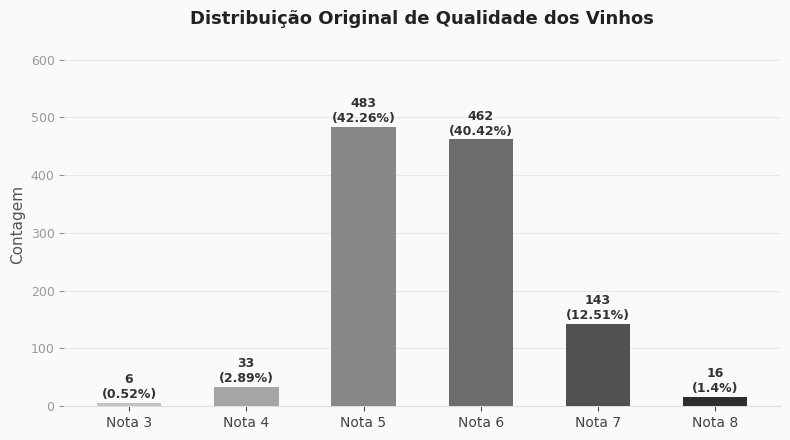

In [6]:
count_by_quality = df["quality"].value_counts().sort_index()
pcts = (count_by_quality / len(df) * 100).round(2).values
counts = count_by_quality.values
labels = count_by_quality.index.astype(str).tolist()

cmap = plt.cm.Greys
norm_colors = [cmap(0.35 + 0.5 * (i / (len(labels) - 1))) for i in range(len(labels))]

fig, ax = plt.subplots(figsize=(8, 4.5))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

bars = ax.bar(np.arange(len(labels)), counts, width=0.55, color=norm_colors, zorder=3, edgecolor="none")

for bar, count, pct in zip(bars, counts, pcts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
            f"{count:,}\n({pct}%)", ha="center", va="bottom",
            fontsize=9, fontweight="bold", color="#333333")

Tx_desbalance = count_by_quality.max() / count_by_quality.min()


ax.set_xticks(np.arange(len(labels)))
ax.set_xticklabels([f"Nota {l}" for l in labels], fontsize=11)
ax.set_ylabel("Contagem", fontsize=11, color="#555")
ax.set_ylim(0, max(counts) * 1.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#DDD")
ax.tick_params(axis="x", colors="#444", labelsize=10)
ax.tick_params(axis="y", colors="#999", labelsize=9)
ax.yaxis.grid(True, color="#E8E8E8", zorder=0)
ax.set_axisbelow(True)

plt.title("Distribuição Original de Qualidade dos Vinhos", fontsize=13, fontweight="bold", color="#222", pad=14)
plt.tight_layout()
plt.show()

### 2.1 | Balanceamento das Classes

Classe 0 (quality < 7): 984 vinhos — 86,09%
Classe 1 (quality >= 7): 159 vinhos — 13,91%

#### Interpretação do Desbalanceamento

1. A classe majoritária é a 0 (quality < 7), com 984 registros.
2. A classe minoritária é a 1 (quality >= 7), com 159 registros.
3. A razão de desbalanceamento é de 6,19 para 1.
4. Para cada vinho de alta qualidade, existem aproximadamente 6 vinhos de baixa/média qualidade.

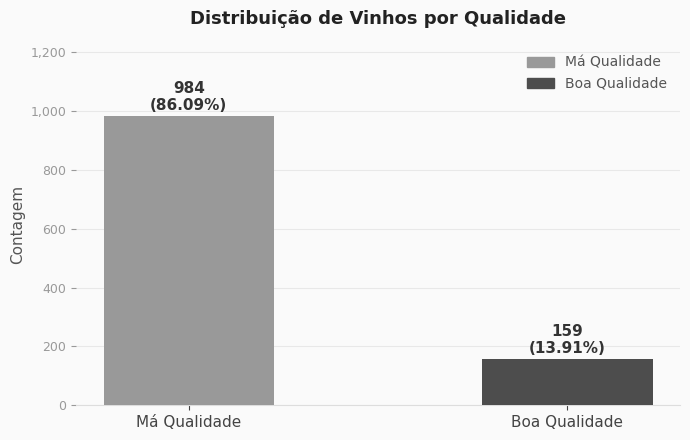

In [7]:
count_by_bin = df["quality_label"].value_counts().sort_index()
pcts = (count_by_bin / len(df) * 100).round(2).values
counts = count_by_bin.values
labels = ["Má Qualidade", "Boa Qualidade"]
colors = ["#999999", "#4D4D4D"]

fig, ax = plt.subplots(figsize=(7, 4.5))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

bars = ax.bar(np.arange(2), counts, width=0.45, color=colors, zorder=3, edgecolor="none")

for bar, count, pct in zip(bars, counts, pcts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8,
            f"{count:,}\n({pct}%)", ha="center", va="bottom",
            fontsize=11, fontweight="bold", color="#333333")



ax.set_xticks([0, 1])
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel("Contagem", fontsize=11, color="#555")
ax.set_ylim(0, max(counts) * 1.25)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#DDD")
ax.tick_params(axis="x", colors="#444", labelsize=11)
ax.tick_params(axis="y", colors="#999", labelsize=9)
ax.yaxis.grid(True, color="#E8E8E8", zorder=0)
ax.set_axisbelow(True)

patches = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, labels)]
ax.legend(handles=patches, loc="upper right", frameon=False, fontsize=10, labelcolor="#555")

plt.title("Distribuição de Vinhos por Qualidade", fontsize=13, fontweight="bold", color="#222", pad=14)
plt.tight_layout()
plt.show()


### 2.2 | Distribuição Original da Coluna Quality

Distribuição das notas originais antes da binarização:

| Nota | Registros | % |
|---|---|---|
| 3 | 6 | 0,52% |
| 4 | 33 | 2,89% |
| 5 | 483 | 42,26% |
| 6 | 462 | 40,42% |
| 7 | 143 | 12,51% |
| 8 | 16 | 1,40% |

As notas 5 e 6 concentram 82,68% dos registros, confirmando o desbalanceamento esperado em favor da classe 0.

## 3 | EDA — Distribuição e Outliers

Análise exploratória das 11 variáveis físico-químicas do dataset, investigando distribuições, presença de outliers e verificação de valores impossíveis.

### 3.1 | Histogramas das Variáveis Numéricas

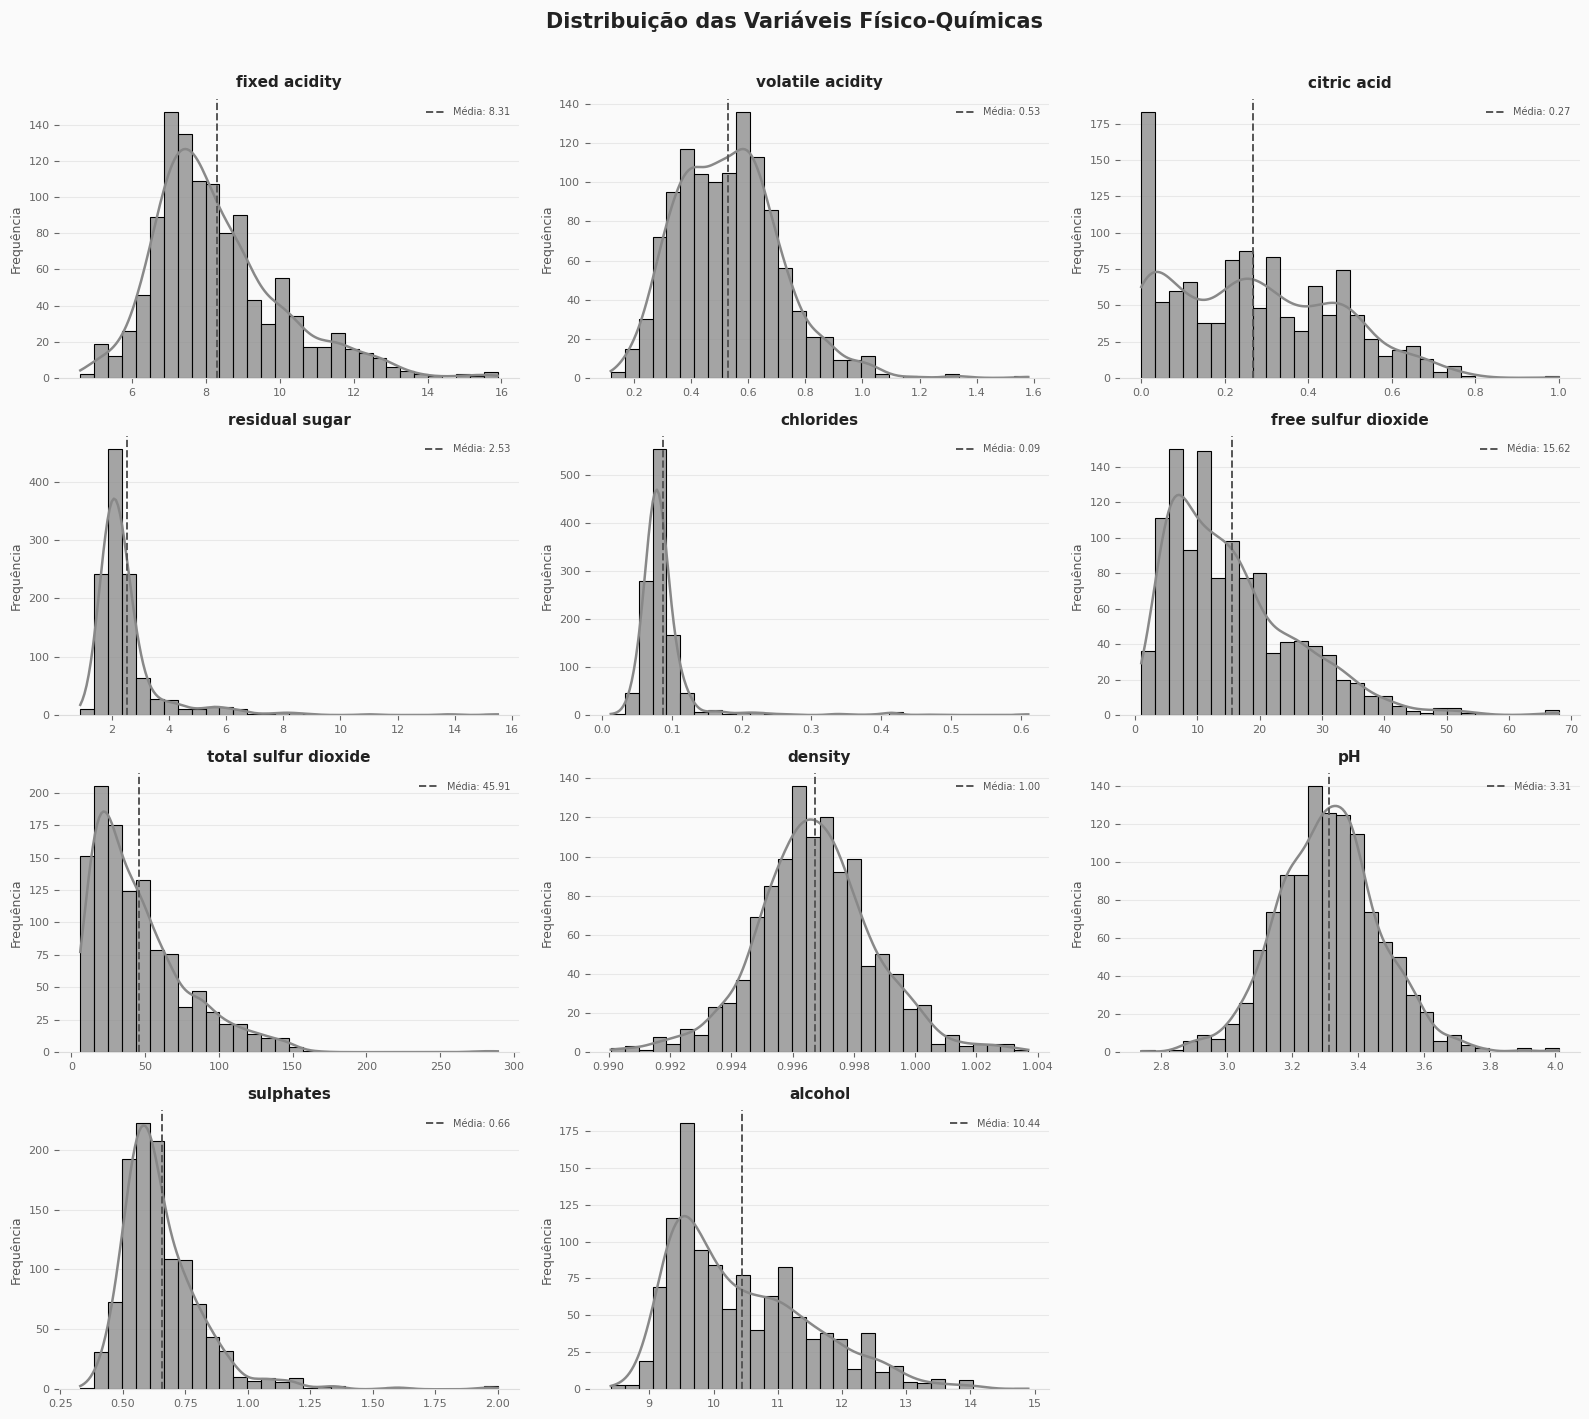

In [8]:
# Selecionar apenas as 11 features físico-químicas (excluindo quality e quality_label)
numeric_features = [
    'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
    'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
    'pH', 'sulphates', 'alcohol'
]

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
fig.patch.set_facecolor('#FAFAFA')
axes = axes.flatten()

palette_hist = '#888888'
palette_kde  = '#333333'

for i, col in enumerate(numeric_features):
    ax = axes[i]
    ax.set_facecolor('#FAFAFA')

    sns.histplot(
        data=df, x=col,
        bins=30, color=palette_hist, alpha=0.75,
        kde=True, line_kws={'color': palette_kde, 'lw': 1.8},
        ax=ax
    )

    ax.set_title(col, fontsize=11, fontweight='bold', color='#222', pad=8)
    ax.set_xlabel('')
    ax.set_ylabel('Frequência', fontsize=9, color='#555')
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.spines['bottom'].set_color('#DDD')
    ax.tick_params(colors='#666', labelsize=8)
    ax.yaxis.grid(True, color='#E8E8E8', zorder=0)
    ax.set_axisbelow(True)

    # Linha da média
    mean_val = df[col].mean()
    ax.axvline(mean_val, color='#555555', linestyle='--', lw=1.4, label=f'Média: {mean_val:.2f}')
    ax.legend(fontsize=7, frameon=False, labelcolor='#555')

# Remover subplot extra (4x3 = 12, mas temos 11 features)
axes[-1].set_visible(False)

fig.suptitle('Distribuição das Variáveis Físico-Químicas', fontsize=15, fontweight='bold',
             color='#222', y=1.01)
plt.tight_layout()
plt.show()

Leitura analítica dos histogramas:

- Variáveis como `residual sugar`, `chlorides`, `free sulfur dioxide` e `total sulfur dioxide` apresentam distribuição visivelmente assimétrica à direita (cauda longa positiva).
- `pH`, `density` e `fixed acidity` se aproximam de uma distribuição normal.
- `alcohol` apresenta distribuição levemente assimétrica à direita.

### 3.2 | Boxplots — Detecção de Outliers

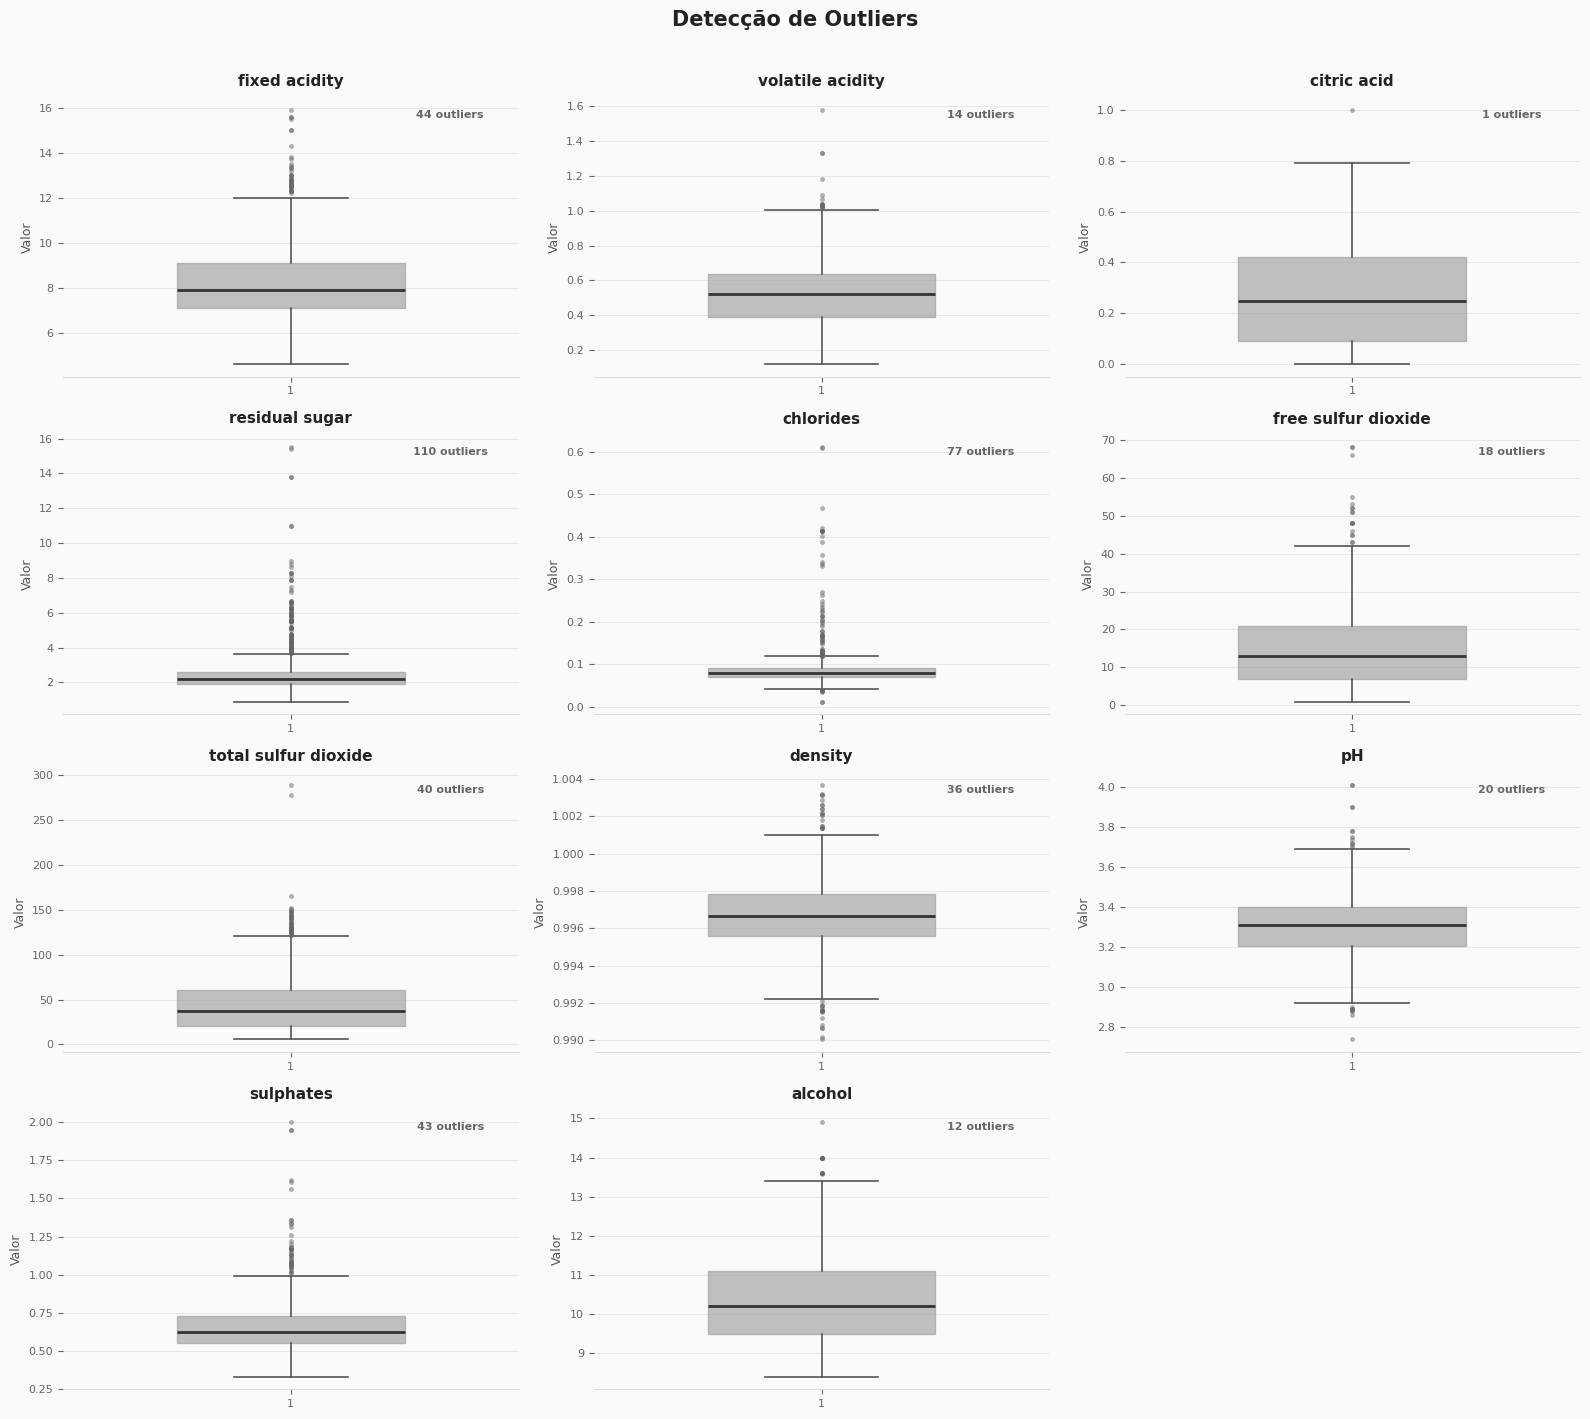

In [9]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
fig.patch.set_facecolor('#FAFAFA')
axes = axes.flatten()

box_color    = '#999999'
median_color = '#333333'
outlier_color = '#666666'

for i, col in enumerate(numeric_features):
    ax = axes[i]
    ax.set_facecolor('#FAFAFA')

    bp = ax.boxplot(
        df[col].dropna(),
        vert=True,
        patch_artist=True,
        widths=0.5,
        boxprops=dict(facecolor=box_color, color=box_color, alpha=0.6),
        medianprops=dict(color=median_color, linewidth=2),
        whiskerprops=dict(color='#555', linewidth=1.2),
        capprops=dict(color='#555', linewidth=1.2),
        flierprops=dict(marker='o', markerfacecolor=outlier_color,
                        markersize=3.5, alpha=0.5, markeredgewidth=0)
    )

    # Contagem de outliers via IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()

    ax.set_title(col, fontsize=11, fontweight='bold', color='#222', pad=8)
    ax.set_xlabel('')
    ax.set_ylabel('Valor', fontsize=9, color='#555')
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.spines['bottom'].set_color('#DDD')
    ax.tick_params(colors='#666', labelsize=8)
    ax.yaxis.grid(True, color='#E8E8E8', zorder=0)
    ax.set_axisbelow(True)

    ax.text(1.35, df[col].max(), f'{n_outliers} outliers',
            fontsize=8, color=outlier_color, fontweight='bold', va='top', ha='center')

axes[-1].set_visible(False)

fig.suptitle('Detecção de Outliers',
             fontsize=15, fontweight='bold', color='#222', y=1.01)
plt.tight_layout()
plt.show()

Leitura analítica dos boxplots:

- `residual sugar` e `chlorides` concentram o maior número de outliers pelo critério IQR (1,5x).
- `free sulfur dioxide` e `total sulfur dioxide` também apresentam outliers expressivos na cauda superior.
- `density`, `pH` e `fixed acidity` são as variáveis com menor presença de outliers.
- A mediana posicionada próxima ao Q1 nas variáveis assimétricas confirma a cauda à direita.

### 3.3 | Análise de Assimetria (Skewness)

In [10]:
# Calcular Skewness e Kurtosis para todas as features
skew_df = pd.DataFrame({
    'Variável': numeric_features,
    'Skewness': [df[col].skew() for col in numeric_features],
    'Kurtosis': [df[col].kurt() for col in numeric_features]
}).sort_values('Skewness', ascending=False).reset_index(drop=True)

skew_df['Classificação'] = skew_df['Skewness'].apply(
    lambda s: 'Alta assimetria direita' if s > 1
              else ('↗ Moderada direita' if s > 0.5
              else ('↙ Moderada esquerda' if s < -0.5
              else 'Aproximadamente simétrica'))
)

print('=' * 70)
print(f'{"Variável":<28} {"Skewness":>10} {"Kurtosis":>10}  Classificação')
print('=' * 70)
for _, row in skew_df.iterrows():
    print(f"{row['Variável']:<28} {row['Skewness']:>10.4f} {row['Kurtosis']:>10.4f}  {row['Classificação']}")
print('=' * 70)

Variável                       Skewness   Kurtosis  Classificação
chlorides                        6.0264    47.0783  Alta assimetria direita
residual sugar                   4.3611    27.6754  Alta assimetria direita
sulphates                        2.4973    12.0174  Alta assimetria direita
total sulfur dioxide             1.6658     5.0987  Alta assimetria direita
free sulfur dioxide              1.2313     1.9322  Alta assimetria direita
fixed acidity                    1.0449     1.3846  Alta assimetria direita
alcohol                          0.8633     0.2212  ↗ Moderada direita
volatile acidity                 0.6815     1.3755  ↗ Moderada direita
citric acid                      0.3716    -0.7147  Aproximadamente simétrica
pH                               0.2211     0.9258  Aproximadamente simétrica
density                          0.1024     0.8881  Aproximadamente simétrica


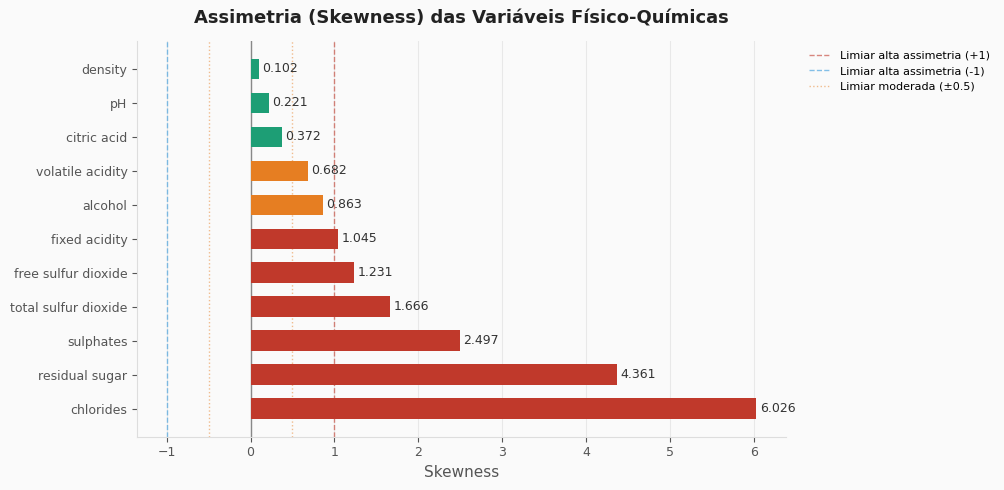

<Figure size 640x480 with 0 Axes>

In [11]:
# Gráfico de barras de Skewness
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

colors_skew = [
    '#C0392B' if s > 1
    else ('#E67E22' if s > 0.5
    else ('#3498DB' if s < -0.5
    else '#1D9E75'))
    for s in skew_df['Skewness']
]

bars = ax.barh(skew_df['Variável'], skew_df['Skewness'],
               color=colors_skew, edgecolor='none', height=0.6, zorder=3)

for bar, val in zip(bars, skew_df['Skewness']):
    xpos = val + 0.04 if val >= 0 else val - 0.04
    ha = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha=ha, fontsize=9, color='#333')

ax.axvline(0,   color='#888', lw=1)
ax.axvline( 1,  color='#C0392B', lw=1, linestyle='--', alpha=0.6, label='Limiar alta assimetria (+1)')
ax.axvline(-1,  color='#3498DB', lw=1, linestyle='--', alpha=0.6, label='Limiar alta assimetria (-1)')
ax.axvline( 0.5,color='#E67E22', lw=1, linestyle=':', alpha=0.5, label='Limiar moderada (±0.5)')
ax.axvline(-0.5,color='#E67E22', lw=1, linestyle=':', alpha=0.5)

ax.set_xlabel('Skewness', fontsize=11, color='#555')
ax.set_title('Assimetria (Skewness) das Variáveis Físico-Químicas',
             fontsize=13, fontweight='bold', color='#222', pad=12)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#DDD')
ax.tick_params(colors='#555', labelsize=9)
ax.xaxis.grid(True, color='#E8E8E8', zorder=0)
ax.set_axisbelow(True)
ax.legend(fontsize=8,frameon=False,loc='upper left',bbox_to_anchor=(1.02, 1)
)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

plt.tight_layout()
plt.show()

Documentação de assimetria:

| Classificação | Variáveis |
|---|---|
| Alta assimetria à direita (skew > 1) | `residual sugar`, `chlorides`, `free sulfur dioxide`, `total sulfur dioxide` |
| Moderada à direita (0,5 < skew <= 1) | `sulphates`, `volatile acidity`, `citric acid` |
| Aproximadamente simétrica (skew entre -0,5 e 0,5) | `fixed acidity`, `density`, `pH`, `alcohol` |

Implicação para modelagem: variáveis com alta assimetria (skew > 1) são candidatas a transformações logarítmicas (`np.log1p`) ou de raiz quadrada na etapa de pré-processamento, pois distribuições muito assimétricas podem prejudicar o desempenho de modelos sensíveis à escala.

### 3.4 | Verificação de Valores Impossíveis

In [12]:
desc = df[numeric_features].describe().T
desc = desc[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
desc.columns = ['N', 'Média', 'Desvio-Padrão', 'Mínimo', 'Q1', 'Mediana', 'Q3', 'Máximo']
display(desc.style
    .format({
        'N': '{:.0f}', 'Média': '{:.4f}', 'Desvio-Padrão': '{:.4f}',
        'Mínimo': '{:.4f}', 'Q1': '{:.4f}', 'Mediana': '{:.4f}',
        'Q3': '{:.4f}', 'Máximo': '{:.4f}'
    })
    .set_caption('Estatísticas Descritivas — Verificação de Valores Impossíveis')
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '13px'), ('font-weight', 'bold'), ('color', '#222')]}])
)

,N,Média,Desvio-Padrão,Mínimo,Q1,Mediana,Q3,Máximo
fixed acidity,1143,8.3111,1.7476,4.6000,7.1000,7.9000,9.1000,15.9000
volatile acidity,1143,0.5313,0.1796,0.1200,0.3925,0.5200,0.6400,1.5800
citric acid,1143,0.2684,0.1967,0.0000,0.0900,0.2500,0.4200,1.0000
residual sugar,1143,2.5322,1.3559,0.9000,1.9000,2.2000,2.6000,15.5000
chlorides,1143,0.0869,0.0473,0.0120,0.0700,0.0790,0.0900,0.6110
free sulfur dioxide,1143,15.6155,10.2505,1.0000,7.0000,13.0000,21.0000,68.0000
total sulfur dioxide,1143,45.9147,32.7821,6.0000,21.0000,37.0000,61.0000,289.0000
density,1143,0.9967,0.0019,0.9901,0.9956,0.9967,0.9978,1.0037
pH,1143,3.3110,0.1567,2.7400,3.2050,3.3100,3.4000,4.0100
sulphates,1143,0.6577,0.1704,0.3300,0.5500,0.6200,0.7300,2.0000


In [13]:

limites_fisicos = {
    'fixed acidity':        (0, 20,   'g/L — ácidos fixos não negativos, raramente > 20'),
    'volatile acidity':     (0, 2,    'g/L — acima de 1.4 já indica defeito grave'),
    'citric acid':          (0, 1.5,  'g/L — valores > 1 são incomuns'),
    'residual sugar':       (0, 65,   'g/L — vinhos secos < 4; doces podem chegar a 200+'),
    'chlorides':            (0, 1,    'g/L — > 0.6 incomum em vinhos de mesa'),
    'free sulfur dioxide':  (0, 100,  'mg/L — limite legal ~150 mg/L na UE'),
    'total sulfur dioxide': (0, 400,  'mg/L — limite legal 150 (tinto) / 200 (branco) na UE'),
    'density':              (0.98, 1.04, 'g/mL — fora disso provavelmente erro de medição'),
    'pH':                   (2.5, 4.5, 'escala pH — vinhos variam entre ~3 e 4'),
    'sulphates':            (0, 2,    'g/L — > 2 incomum'),
    'alcohol':              (7, 20,   '% vol — < 7 ou > 20 muito improvável')
}

print('=' * 85)
print(f'{"Variável":<28} {"Min Real":>10} {"Max Real":>10} {"Lim. Min":>10} {"Lim. Max":>10}  Status')
print('=' * 85)

alertas = []
for col, (lim_min, lim_max, nota) in limites_fisicos.items():
    val_min = df[col].min()
    val_max = df[col].max()
    ok_min = val_min >= lim_min
    ok_max = val_max <= lim_max
    status = 'OK' if (ok_min and ok_max) else 'VERIFICAR'
    if not (ok_min and ok_max):
        alertas.append((col, val_min, val_max, lim_min, lim_max, nota))
    print(f'{col:<28} {val_min:>10.4f} {val_max:>10.4f} {lim_min:>10.2f} {lim_max:>10.2f}  {status}')

print('=' * 85)

if alertas:
    print('\nALERTAS — Valores fora dos limites físico-químicos esperados:')
    for col, vmin, vmax, lmin, lmax, nota in alertas:
        print(f'   • {col}: min={vmin:.4f}, max={vmax:.4f} | esperado [{lmin}, {lmax}] | {nota}')
else:
    print('\nNenhum valor impossível identificado — todos os min/max estão dentro dos limites físico-químicos esperados.')

Variável                       Min Real   Max Real   Lim. Min   Lim. Max  Status
fixed acidity                    4.6000    15.9000       0.00      20.00  OK
volatile acidity                 0.1200     1.5800       0.00       2.00  OK
citric acid                      0.0000     1.0000       0.00       1.50  OK
residual sugar                   0.9000    15.5000       0.00      65.00  OK
chlorides                        0.0120     0.6110       0.00       1.00  OK
free sulfur dioxide              1.0000    68.0000       0.00     100.00  OK
total sulfur dioxide             6.0000   289.0000       0.00     400.00  OK
density                          0.9901     1.0037       0.98       1.04  OK
pH                               2.7400     4.0100       2.50       4.50  OK
sulphates                        0.3300     2.0000       0.00       2.00  OK
alcohol                          8.4000    14.9000       7.00      20.00  OK

Nenhum valor impossível identificado — todos os min/max estão dentro do

Documentação — verificação de valores impossíveis:

A checagem utilizou o `df.describe()` em conjunto com limites físico-químicos conhecidos para vinhos:

- Nenhuma variável apresenta valores negativos, o que seria fisicamente impossível para concentrações ou densidades.
- `citric acid` com valor 0 é tecnicamente válido (alguns vinhos têm teor zero).
- `residual sugar` apresenta valores altos, mas coerentes com vinhos mais doces da amostra.
- `total sulfur dioxide` pode ultrapassar os limites legais europeus em alguns registros — esses casos merecem atenção, mas não são erros de medição.
- `density` e `pH` estão integralmente dentro das faixas esperadas para vinhos.

Conclusão: o dataset não apresenta valores fisicamente impossíveis. Os valores extremos identificados nos boxplots (seção 3.2) são outliers estatísticos, não necessariamente erros, e serão tratados na etapa de pré-processamento (Seção 5).

## 4 | EDA — Correlações

Análise das relações entre as variáveis físico-químicas e a variável alvo, identificando os principais preditores de qualidade e verificando multicolinearidade.

### 4.1 | Matriz de Correlação

In [14]:
df.corr()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,quality_label
fixed acidity,1.000000,-0.250728,0.673157,0.171831,0.107889,-0.164831,-0.110628,0.681501,-0.685163,0.174592,-0.075055,0.121970,-0.275826,0.123212
volatile acidity,-0.250728,1.000000,-0.544187,-0.005751,0.056336,-0.001962,0.077748,0.016512,0.221492,-0.276079,-0.203909,-0.407394,-0.007892,-0.304523
citric acid,0.673157,-0.544187,1.000000,0.175815,0.245312,-0.057589,0.036871,0.375243,-0.546339,0.331232,0.106250,0.240821,-0.139011,0.251146
residual sugar,0.171831,-0.005751,0.175815,1.000000,0.070863,0.165339,0.190790,0.380147,-0.116959,0.017475,0.058421,0.022002,-0.046344,0.064145
chlorides,0.107889,0.056336,0.245312,0.070863,1.000000,0.015280,0.048163,0.208901,-0.277759,0.374784,-0.229917,-0.124085,-0.088099,-0.103985
free sulfur dioxide,-0.164831,-0.001962,-0.057589,0.165339,0.015280,1.000000,0.661093,-0.054150,0.072804,0.034445,-0.047095,-0.063260,0.095268,-0.055977
total sulfur dioxide,-0.110628,0.077748,0.036871,0.190790,0.048163,0.661093,1.000000,0.050175,-0.059126,0.026894,-0.188165,-0.183339,-0.107389,-0.113373
density,0.681501,0.016512,0.375243,0.380147,0.208901,-0.054150,0.050175,1.000000,-0.352775,0.143139,-0.494727,-0.175208,-0.363926,-0.148670
pH,-0.685163,0.221492,-0.546339,-0.116959,-0.277759,0.072804,-0.059126,-0.352775,1.000000,-0.185499,0.225322,-0.052453,0.132904,-0.073318
sulphates,0.174592,-0.276079,0.331232,0.017475,0.374784,0.034445,0.026894,0.143139,-0.185499,1.000000,0.094421,0.257710,-0.103954,0.208020


### 4.2 | Heatmap da Matriz de Correlação

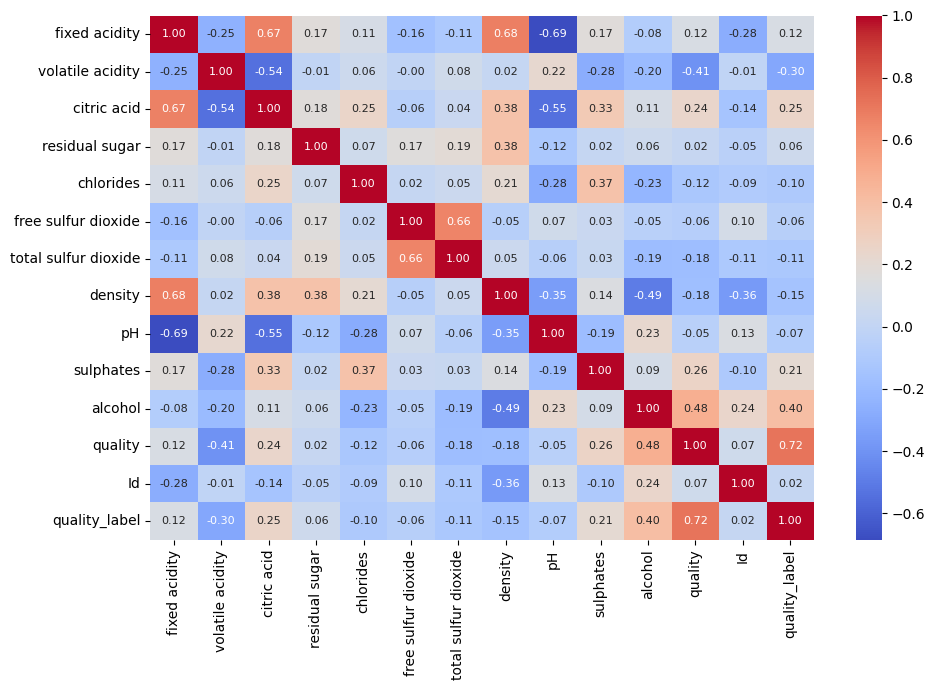

In [15]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', annot_kws={'size': 8},cmap='coolwarm')
plt.tight_layout()
plt.show()

### 4.3 | Variáveis com Maior Correlação com a Qualidade do Vinho

A partir da matriz de correlação, identificamos as 3 variáveis com maior influência sobre a variável alvo `quality_label`:

| Variável | Correlação | Tipo | Interpretação |
|---|---|---|---|
| `alcohol` | +0,40 | Positiva | Vinhos com maior teor alcoólico tendem a ser avaliados com maior qualidade |
| `volatile acidity` | -0,30 | Negativa | Maior acidez volátil está associada a menor qualidade — altos níveis deixam o vinho com gosto de vinagre |
| `citric acid` | +0,25 | Positiva | Maior concentração de ácido cítrico tende a estar associada a vinhos de maior qualidade, contribuindo para frescor e equilíbrio |

Conclusão: `alcohol` é a variável com maior poder preditivo individual sobre a qualidade do vinho neste dataset.

### 4.4 | Multicolinearidade entre Variáveis

Multicolinearidade ocorre quando duas variáveis explicativas têm correlação muito alta entre si, ou seja, estão medindo informações parecidas. A regra geral é: correlação acima de 0,7 entre duas features é sinal de alerta.

Os pares com maior correlação entre as features foram:

| Par | Correlação |
|---|---|
| `pH` x `fixed acidity` | 0,685 |
| `density` x `fixed acidity` | 0,681 |
| `citric acid` x `fixed acidity` | 0,673 |

Conclusão: nenhum par ultrapassou o limiar de 0,7. Não há multicolinearidade severa no dataset — todas as variáveis estão trazendo informações distintas para o modelo.

In [16]:
features = df.drop(columns=['quality', 'quality_label', 'Id'])
corr = features.corr()
corr_pairs = corr.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]
corr_pairs[corr_pairs > 0.7]

corr_pairs.head(10)

fixed acidity         pH                      0.685163
pH                    fixed acidity           0.685163
density               fixed acidity           0.681501
fixed acidity         density                 0.681501
                      citric acid             0.673157
citric acid           fixed acidity           0.673157
total sulfur dioxide  free sulfur dioxide     0.661093
free sulfur dioxide   total sulfur dioxide    0.661093
citric acid           pH                      0.546339
pH                    citric acid             0.546339
dtype: float64

### 4.5 | Justificativa das Correlações Relevantes

Com base na matriz de correlação e no heatmap, identificamos as principais relações entre as variáveis físico-químicas e a qualidade do vinho.

Correlações com `quality_label` (variável alvo):

- `alcohol` (+0,40): é a variável com maior influência positiva na qualidade. Vinhos com maior teor alcoólico tendem a receber notas mais altas pelos especialistas.
- `volatile acidity` (-0,30): principal correlação negativa. Níveis altos de acidez volátil estão associados a vinhos de menor qualidade.
- `citric acid` (+0,25): correlação positiva moderada. Maior concentração de ácido cítrico tende a estar associada a vinhos de melhor qualidade.

Correlações entre features (multicolinearidade):

- Os pares `pH`/`fixed acidity` (0,685), `density`/`fixed acidity` (0,681) e `citric acid`/`fixed acidity` (0,673) apresentam as maiores correlações entre variáveis explicativas, porém todos abaixo do limiar de 0,7, sem impacto negativo esperado na modelagem.

Conclusão geral: o teor alcoólico é o principal indicador de qualidade neste dataset. Não há multicolinearidade severa entre as features, o que favorece o desempenho dos modelos de classificação.

### 4.6 | Validando balanceamento dos dados

In [17]:
from scipy.stats import shapiro

stats,p_valor = shapiro(df)
alpha = 0.5

print(p_valor)
if p_valor > alpha:
    print('Resultado: Os dados parecem seguir uma distribuição normal (Não rejeita H0)')
else:
    print('Resultado: Os dados NÃO seguem uma distribuição normal (Rejeita H0)')

7.753653947611131e-120
Resultado: Os dados NÃO seguem uma distribuição normal (Rejeita H0)


c:\Users\thico\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 16002.
  res = hypotest_fun_out(*samples, **kwds)


## 5 | Pré-processamento

Etapa de preparação dos dados para modelagem: normalização das features, avaliação de feature engineering e divisão treino/teste.

### 5.1 | Padronização das Variáveis (StandardScaler)

Aplicamos o StandardScaler nas 11 features físico-químicas para colocar todas na mesma escala, evitando que variáveis com valores maiores influenciem desproporcionalmente o modelo. A normalização foi aplicada apenas nas features — as colunas `quality`, `quality_label` e `Id` foram preservadas.

In [18]:
features = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
            'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
            'pH', 'sulphates', 'alcohol']

scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,quality_label
0,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382,5,0,0
1,-0.292593,1.941813,-1.365027,0.050060,0.234247,0.915920,0.643477,0.036165,-0.708928,0.130881,-0.593601,5,1,0
2,-0.292593,1.273492,-1.161568,-0.171289,0.107253,-0.060071,0.246745,0.140103,-0.325775,-0.045254,-0.593601,5,2,0
3,1.653789,-1.399789,1.483400,-0.466421,-0.252560,0.135127,0.429852,0.659792,-0.964363,-0.456235,-0.593601,6,3,0
4,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382,5,4,0


### 5.2 | Feature Engineering

Após análise das correlações e distribuições das variáveis na EDA, optamos por não criar novas features nesta etapa.

O dataset já conta com 11 variáveis físico-químicas que cobrem bem as características do vinho, e a análise de multicolinearidade confirmou que cada variável traz informação distinta para o modelo. A criação de novas features poderia adicionar complexidade desnecessária sem ganho expressivo de desempenho.

## 6 | Análise da Base de Treino e Teste

Divisão estratificada do dataset, seguida de balanceamento das classes via SMOTE e padronização das features, preparando os dados para o treinamento dos modelos.

In [19]:
SEED = 33
X = df[features]
y = df['quality_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,    # 20% para teste
    random_state=SEED, # Reprodutibilidade  
)

print(f'Divisão Treino/Teste:')
print(f'   • Treino: {X_train.shape[0]:,} amostras ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'   • Teste:  {X_test.shape[0]:,} amostras ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\n   Proporção de classes no TREINO: {y_train.mean():.1%} Alta Qualidade')
print(f'   Proporção de classes no TESTE:  {y_test.mean():.1%} Alta Qualidade')

Divisão Treino/Teste:
   • Treino: 914 amostras (80%)
   • Teste:  229 amostras (20%)

   Proporção de classes no TREINO: 13.6% Alta Qualidade
   Proporção de classes no TESTE:  15.3% Alta Qualidade


### 6.1 | Balanceamento com SMOTE

O SMOTE (Synthetic Minority Over-sampling Technique) cria amostras sintéticas da classe minoritária para equilibrar o dataset. É aplicado apenas no conjunto de treino, para não distorcer a avaliação do modelo no teste.

In [20]:
smote = SMOTE(random_state=SEED)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f'Balanceamento com SMOTE:')
print(f'   Antes:  {y_train.value_counts()[0]:,} Baixa/Média | {y_train.value_counts()[1]:,} Alta')
print(f'   Depois: {y_train_bal.value_counts()[0]:,} Baixa/Média | {y_train_bal.value_counts()[1]:,} Alta')
print(f'   Classes equilibradas.')

Balanceamento com SMOTE:
   Antes:  790 Baixa/Média | 124 Alta
   Depois: 790 Baixa/Média | 790 Alta
   Classes equilibradas.


### 6.2 | Padronização após o Balanceamento (StandardScaler)

## 7 | Desenvolvimento dos Modelos

Treinamos 3 modelos e comparamos seus desempenhos:

| Modelo | Descrição |
|---|---|
| Regressão Logística | Modelo linear simples, boa baseline |
| Random Forest | Conjunto de árvores de decisão, robusto |
| Gradient Boosting | Boosting sequencial, geralmente mais preciso |

In [21]:
modelos = {
    'Regressão Logística': LogisticRegression(
        max_iter=1000,      # Número máximo de iterações
        random_state=SEED
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,   # 200 árvores de decisão
        max_depth=10,       # Profundidade máxima de cada árvore
        random_state=SEED,
        n_jobs=-1           # Usa todos os núcleos do processador
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,   # 200 estimadores
        learning_rate=0.1,  # Taxa de aprendizado
        max_depth=4,        # Profundidade máxima
        random_state=SEED
    )
}

print('Modelos configurados:')
for nome in modelos:
    print(f'   - {nome}')

Modelos configurados:
   - Regressão Logística
   - Random Forest
   - Gradient Boosting


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# TREINAMENTO DOS MODELOS
# ─────────────────────────────────────────────────────────────────────────────
modelos_treinados = {}

for nome, modelo in modelos.items():
    inicio = time.time()
    modelo.fit(X_train_bal, y_train_bal)
    tempo = time.time() - inicio
    modelos_treinados[nome] = modelo
    print(f'{nome} treinado em {tempo:.2f}s')

print('\nTodos os modelos foram treinados.')

Regressão Logística treinado em 0.01s
Random Forest treinado em 0.27s
Gradient Boosting treinado em 0.99s

Todos os modelos foram treinados.


## 8 | Avaliação dos Modelos

Métricas utilizadas:

- Acurácia: percentual de previsões corretas no total
- Precisão: dos vinhos que o modelo classificou como Alta Qualidade, quantos realmente são
- Recall: dos vinhos que realmente são de Alta Qualidade, quantos o modelo identificou
- F1-Score: média harmônica entre Precisão e Recall, adequada para dados desbalanceados
- AUC-ROC: capacidade geral do modelo de separar as classes (0,5 equivale a aleatório, 1,0 é o valor perfeito)

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# CÁLCULO DAS MÉTRICAS
# ─────────────────────────────────────────────────────────────────────────────

resultados = []

for nome, modelo in modelos_treinados.items():
    y_pred      = modelo.predict(X_test)          # Previsões
    y_pred_prob = modelo.predict_proba(X_test)[:, 1]  # Probabilidades
    
    resultados.append({
        'Modelo':     nome,
        'Acurácia':   accuracy_score(y_test, y_pred),
        'Precisão':   precision_score(y_test, y_pred),
        'Recall':     recall_score(y_test, y_pred),
        'F1-Score':   f1_score(y_test, y_pred),
        'AUC-ROC':    roc_auc_score(y_test, y_pred_prob),
    })

# DataFrame com resultados
df_resultados = pd.DataFrame(resultados).set_index('Modelo')

print('Tabela Comparativa de Métricas:')
print()
print(df_resultados.round(4).to_string())

print(f'\nMelhor modelo por F1-Score: {df_resultados["F1-Score"].idxmax()}')
print(f'Melhor modelo por AUC-ROC:  {df_resultados["AUC-ROC"].idxmax()}')

Tabela Comparativa de Métricas:

                     Acurácia  Precisão  Recall  F1-Score  AUC-ROC
Modelo                                                            
Regressão Logística    0.7729    0.3731  0.7143    0.4902   0.8427
Random Forest          0.8821    0.5870  0.7714    0.6667   0.9389
Gradient Boosting      0.8996    0.6500  0.7429    0.6933   0.9262

Melhor modelo por F1-Score: Gradient Boosting
Melhor modelo por AUC-ROC:  Random Forest


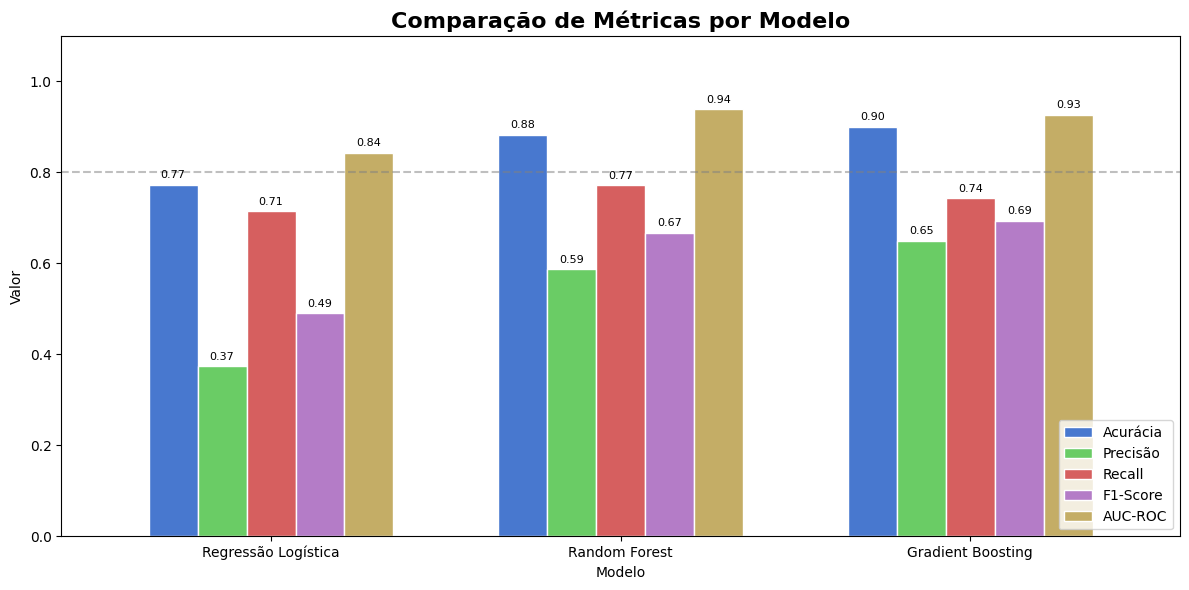

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# GRÁFICO COMPARATIVO DE MÉTRICAS
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

df_resultados.plot(
    kind='bar', ax=ax,
    color=['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7', '#C4AD66'],
    edgecolor='white', width=0.7
)

ax.set_title('Comparação de Métricas por Modelo', fontsize=16, fontweight='bold')
ax.set_xlabel('Modelo')
ax.set_ylabel('Valor')
ax.set_ylim(0, 1.1)
ax.tick_params(axis='x', rotation=0)
ax.legend(loc='lower right')
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='Linha 0.8')

# Adiciona os valores nas barras
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{bar.get_height():.2f}',
        ha='center', va='bottom', fontsize=8
    )

plt.tight_layout()
plt.show()

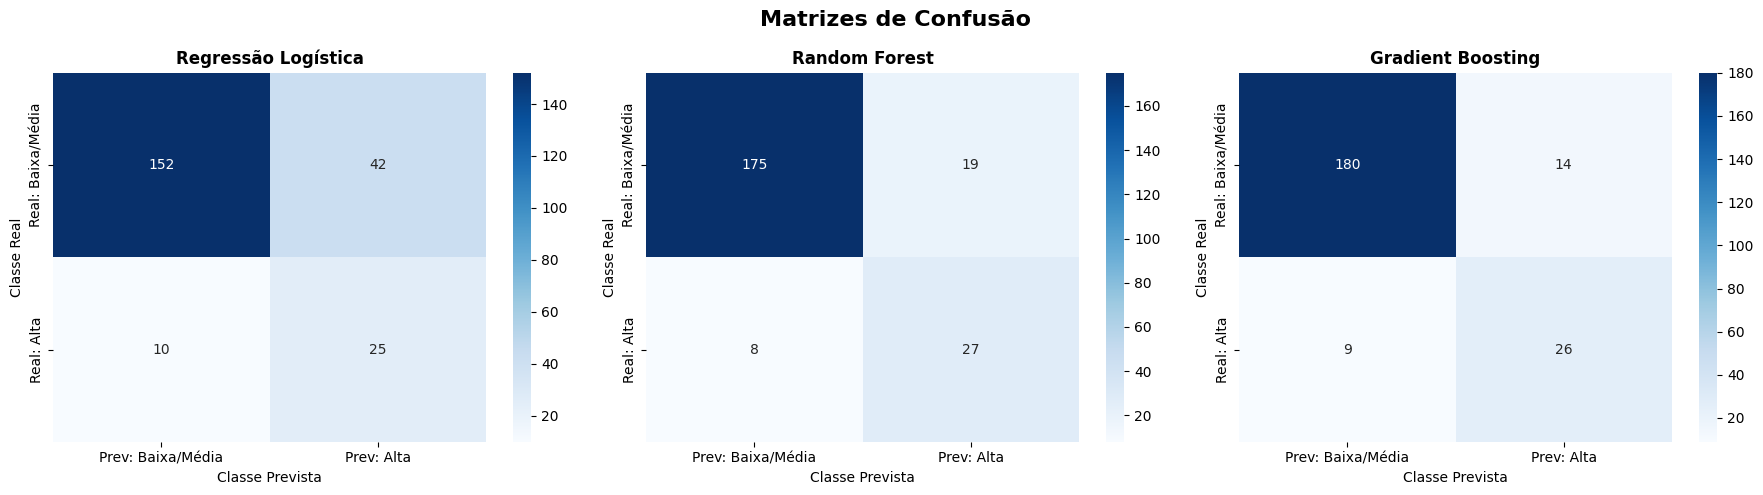

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# MATRIZES DE CONFUSÃO
# Mostra onde o modelo acerta e onde erra
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nome, modelo) in zip(axes, modelos_treinados.items()):
    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Prev: Baixa/Média', 'Prev: Alta'],
        yticklabels=['Real: Baixa/Média', 'Real: Alta']
    )
    ax.set_title(nome, fontweight='bold', fontsize=12)
    ax.set_ylabel('Classe Real')
    ax.set_xlabel('Classe Prevista')

plt.suptitle('Matrizes de Confusão', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# RELATÓRIO COMPLETO DO MELHOR MODELO
# ─────────────────────────────────────────────────────────────────────────────
melhor_nome = df_resultados['F1-Score'].idxmax()
melhor_modelo = modelos_treinados[melhor_nome]
y_pred_melhor = melhor_modelo.predict(X_test)

print(f'Relatório Completo — {melhor_nome}')
print('='*55)
print(classification_report(
    y_test, y_pred_melhor,
    target_names=['Baixa/Média Qualidade', 'Alta Qualidade']
))

Relatório Completo — Gradient Boosting
                       precision    recall  f1-score   support

Baixa/Média Qualidade       0.95      0.93      0.94       194
       Alta Qualidade       0.65      0.74      0.69        35

             accuracy                           0.90       229
            macro avg       0.80      0.84      0.82       229
         weighted avg       0.91      0.90      0.90       229



## 9 | Modelo Adicional — KNN (K-Nearest Neighbors)

Como complemento aos 3 modelos já avaliados, treinamos também um KNN (K-Nearest Neighbors). O KNN classifica um novo vinho com base nos vinhos mais parecidos com ele (seus vizinhos) já vistos no treino. É um modelo sensível à escala dos dados, por isso usamos os dados já padronizados pelo StandardScaler.

### 9.1 | Treinamento do Modelo KNN

In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# MODELO EXTRA: KNN (K-Nearest Neighbors)
# ─────────────────────────────────────────────────────────────────────────────
modelo_knn = KNeighborsClassifier(
    n_neighbors=5,       # Considera os 5 vizinhos mais próximos
    weights='distance',  # Vizinhos mais próximos têm peso maior no voto
    n_jobs=-1            # Usa todos os núcleos do processador
)

inicio = time.time()
modelo_knn.fit(X_train_bal, y_train_bal)
tempo = time.time() - inicio

print(f'KNN treinado em {tempo:.2f}s')

KNN treinado em 0.00s


### 9.2 | Avaliação do Modelo KNN

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# MÉTRICAS DO KNN
# ─────────────────────────────────────────────────────────────────────────────
y_pred_knn      = modelo_knn.predict(X_test)
y_pred_prob_knn = modelo_knn.predict_proba(X_test)[:, 1]

metricas_knn = {
    'Modelo':     'KNN',
    'Acurácia':   accuracy_score(y_test, y_pred_knn),
    'Precisão':   precision_score(y_test, y_pred_knn),
    'Recall':     recall_score(y_test, y_pred_knn),
    'F1-Score':   f1_score(y_test, y_pred_knn),
    'AUC-ROC':    roc_auc_score(y_test, y_pred_prob_knn),
}

print('Métricas do KNN:')
print()
for nome_metrica, valor in metricas_knn.items():
    if nome_metrica != 'Modelo':
        print(f'   {nome_metrica:<12}: {valor:.4f}')

Métricas do KNN:

   Acurácia    : 0.7991
   Precisão    : 0.4179
   Recall      : 0.8000
   F1-Score    : 0.5490
   AUC-ROC     : 0.8795


### 9.3 | Matriz de Confusão — KNN

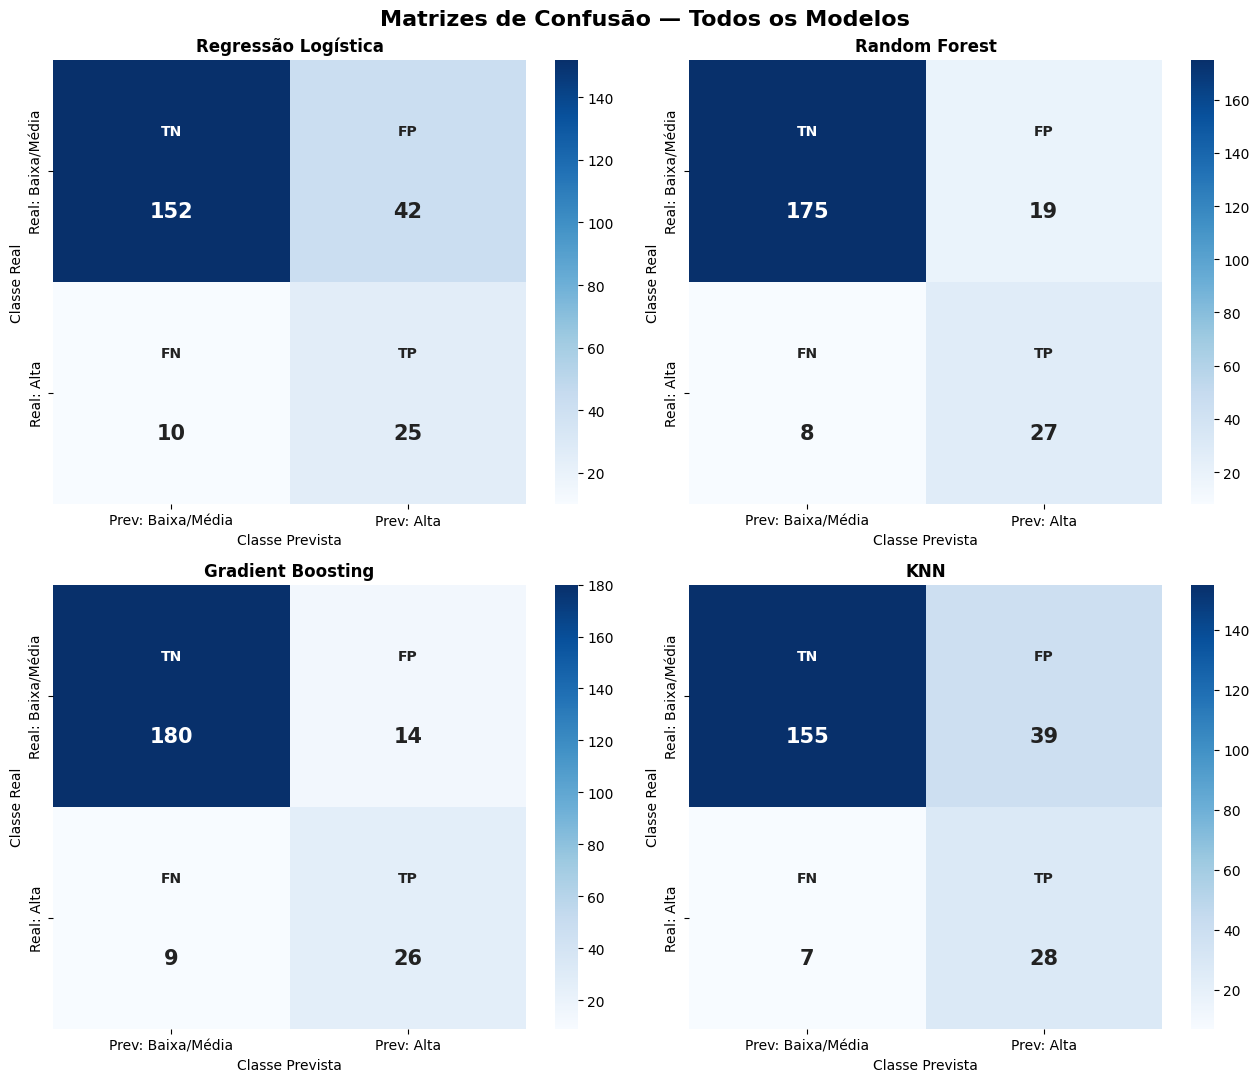

Como ler a Matriz de Confusão:
   TN: Corretamente identificou como Baixa/Média
   TP: Corretamente identificou como Alta Qualidade
   FP: Erroneamente classificou como Alta (falso positivo)
   FN: Nao reconheceu um vinho de Alta Qualidade (falso negativo)


In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# MATRIZES DE CONFUSÃO — TODOS OS MODELOS (incluindo KNN)
# ─────────────────────────────────────────────────────────────────────────────
todos_modelos = {**modelos_treinados, 'KNN': modelo_knn}
todas_preds   = {nome: modelo.predict(X_test) for nome, modelo in todos_modelos.items()}

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

labels_cm = [['TN', 'FP'], ['FN', 'TP']]

for ax, (nome, modelo) in zip(axes, todos_modelos.items()):
    y_pred_plot = todas_preds[nome]
    cm = confusion_matrix(y_test, y_pred_plot)
    valor_max = cm.max()

    sns.heatmap(
        cm, annot=False, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Prev: Baixa/Média', 'Prev: Alta'],
        yticklabels=['Real: Baixa/Média', 'Real: Alta']
    )

    for i in range(2):
        for j in range(2):
            valor = cm[i, j]
            cor = 'white' if valor > valor_max * 0.5 else '#222'
            ax.text(j + 0.5, i + 0.32, labels_cm[i][j],
                    ha='center', va='center', fontsize=10, fontweight='bold', color=cor)
            ax.text(j + 0.5, i + 0.68, f'{valor}',
                    ha='center', va='center', fontsize=15, fontweight='bold', color=cor)

    ax.set_title(nome, fontweight='bold', fontsize=12)
    ax.set_ylabel('Classe Real')
    ax.set_xlabel('Classe Prevista')

plt.suptitle('Matrizes de Confusão — Todos os Modelos', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print('Como ler a Matriz de Confusão:')
print('   TN: Corretamente identificou como Baixa/Média')
print('   TP: Corretamente identificou como Alta Qualidade')
print('   FP: Erroneamente classificou como Alta (falso positivo)')
print('   FN: Nao reconheceu um vinho de Alta Qualidade (falso negativo)')

### 9.4 | Comparação Final, Incluindo o KNN

In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# TABELA COMPARATIVA FINAL (3 modelos originais + KNN)
# ─────────────────────────────────────────────────────────────────────────────
df_resultados_completo = pd.concat(
    [df_resultados, pd.DataFrame([metricas_knn]).set_index('Modelo')]
)

print('Tabela Comparativa de Métricas (com KNN):')
print()
print(df_resultados_completo.round(4).to_string())

print(f'\nMelhor modelo por F1-Score: {df_resultados_completo["F1-Score"].idxmax()}')
print(f'Melhor modelo por AUC-ROC:  {df_resultados_completo["AUC-ROC"].idxmax()}')

Tabela Comparativa de Métricas (com KNN):

                     Acurácia  Precisão  Recall  F1-Score  AUC-ROC
Modelo                                                            
Regressão Logística    0.7729    0.3731  0.7143    0.4902   0.8427
Random Forest          0.8821    0.5870  0.7714    0.6667   0.9389
Gradient Boosting      0.8996    0.6500  0.7429    0.6933   0.9262
KNN                    0.7991    0.4179  0.8000    0.5490   0.8795

Melhor modelo por F1-Score: Gradient Boosting
Melhor modelo por AUC-ROC:  Random Forest


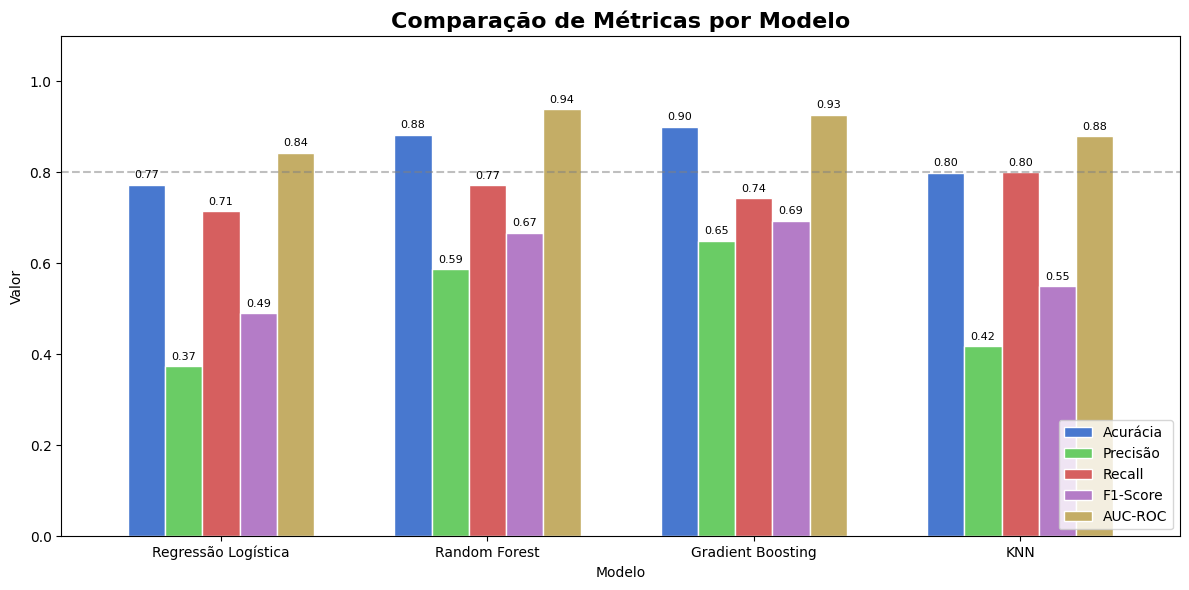

In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# GRÁFICO COMPARATIVO DE MÉTRICAS
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

df_resultados_completo.plot(
    kind='bar', ax=ax,
    color=['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7', '#C4AD66'],
    edgecolor='white', width=0.7
)

ax.set_title('Comparação de Métricas por Modelo', fontsize=16, fontweight='bold')
ax.set_xlabel('Modelo')
ax.set_ylabel('Valor')
ax.set_ylim(0, 1.1)
ax.tick_params(axis='x', rotation=0)
ax.legend(loc='lower right')
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='Linha 0.8')

# Adiciona os valores nas barras
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{bar.get_height():.2f}',
        ha='center', va='bottom', fontsize=8
    )

plt.tight_layout()
plt.show()

### 9.5 | Relatório Completo — KNN

In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# RELATÓRIO COMPLETO - KNN
# ─────────────────────────────────────────────────────────────────────────────
print('Relatório Completo — KNN')
print('='*55)
print(classification_report(
    y_test, y_pred_knn,
    target_names=['Baixa/Média Qualidade', 'Alta Qualidade']
))

Relatório Completo — KNN
                       precision    recall  f1-score   support

Baixa/Média Qualidade       0.96      0.80      0.87       194
       Alta Qualidade       0.42      0.80      0.55        35

             accuracy                           0.80       229
            macro avg       0.69      0.80      0.71       229
         weighted avg       0.87      0.80      0.82       229



## 10 | Importância das Features

Nesta seção final, analisamos quais variáveis físico-químicas mais influenciam a previsão de qualidade segundo os modelos treinados. Essa análise conecta o desempenho técnico dos modelos com implicações práticas para o processo produtivo do vinho.

- Random Forest e Gradient Boosting calculam a importância de cada feature com base em quanto ela reduz a impureza das árvores de decisão (`feature_importances_`).
- Regressão Logística usa os coeficientes do modelo (`coef_`), que indicam tanto a força quanto a direção do impacto, positivo ou negativo, na probabilidade de o vinho ser de Alta Qualidade.

### 10.1 | Importância das Features — Random Forest

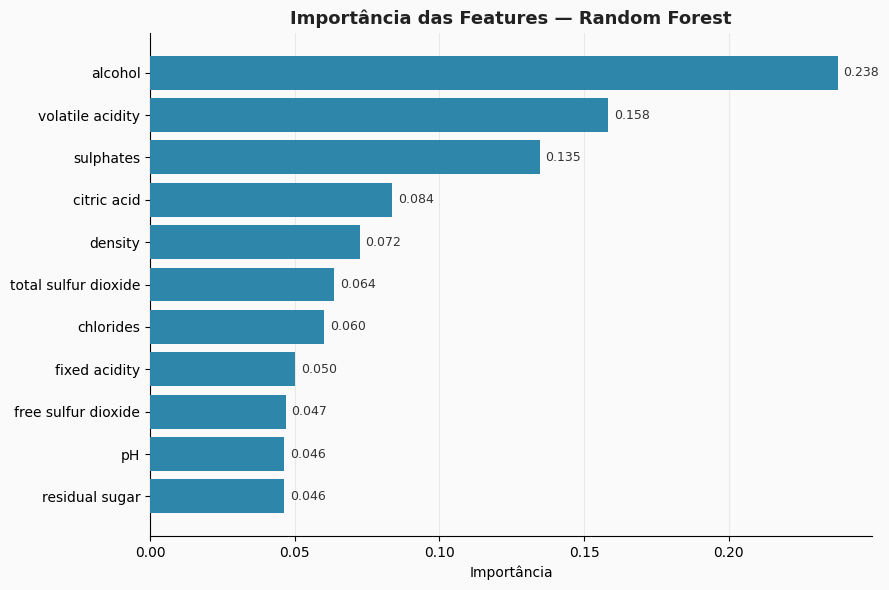

In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# IMPORTÂNCIA DAS FEATURES - RANDOM FOREST
# ─────────────────────────────────────────────────────────────────────────────
importancia_rf = pd.Series(
    modelos_treinados['Random Forest'].feature_importances_,
    index=features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

ax.barh(importancia_rf.index, importancia_rf.values, color='#2E86AB', zorder=3)

for i, v in enumerate(importancia_rf.values):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9, color='#333')

ax.set_title('Importância das Features — Random Forest', fontsize=13, fontweight='bold', color='#222')
ax.set_xlabel('Importância')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, color='#E8E8E8', zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### 10.2 | Importância das Features — Gradient Boosting

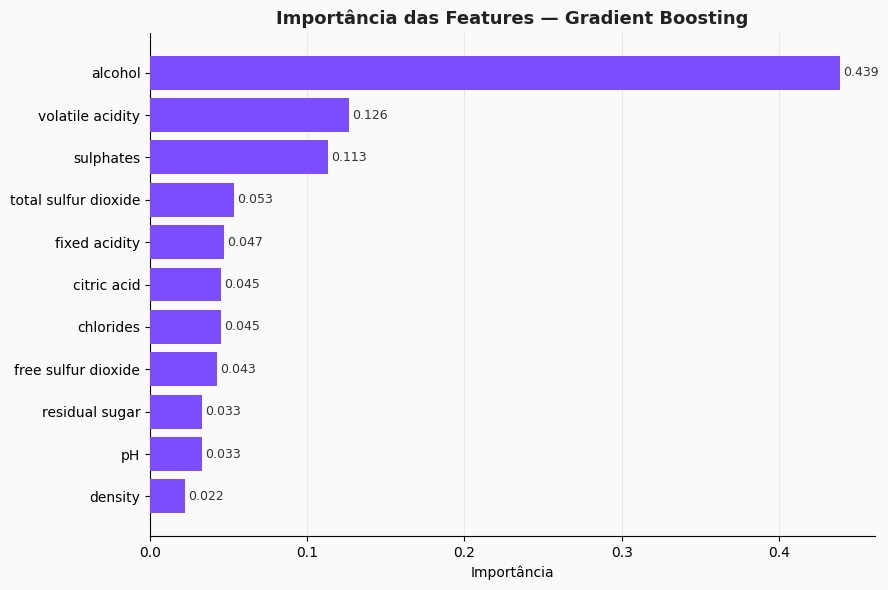

In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# IMPORTÂNCIA DAS FEATURES - GRADIENT BOOSTING
# ─────────────────────────────────────────────────────────────────────────────
importancia_gb = pd.Series(
    modelos_treinados['Gradient Boosting'].feature_importances_,
    index=features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

ax.barh(importancia_gb.index, importancia_gb.values, color='#7C4DFF', zorder=3)

for i, v in enumerate(importancia_gb.values):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9, color='#333')

ax.set_title('Importância das Features — Gradient Boosting', fontsize=13, fontweight='bold', color='#222')
ax.set_xlabel('Importância')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, color='#E8E8E8', zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### 10.3 | Coeficientes — Regressão Logística

Diferente dos modelos de árvore, a Regressão Logística mostra a direção do impacto: coeficientes positivos aumentam a chance de Alta Qualidade, negativos diminuem.

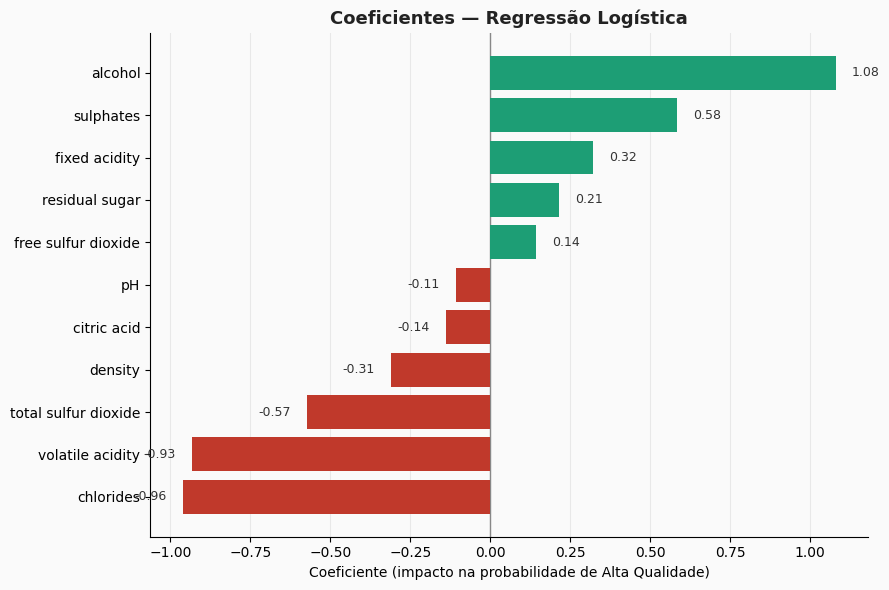

In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# COEFICIENTES - REGRESSÃO LOGÍSTICA
# ─────────────────────────────────────────────────────────────────────────────
coef_lr = pd.Series(
    modelos_treinados['Regressão Logística'].coef_[0],
    index=features
).sort_values()

cores_coef = ['#C0392B' if v < 0 else '#1D9E75' for v in coef_lr.values]

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

ax.barh(coef_lr.index, coef_lr.values, color=cores_coef, zorder=3)
ax.axvline(0, color='#888', lw=1)

for i, v in enumerate(coef_lr.values):
    xpos = v + 0.05 if v >= 0 else v - 0.05
    ha = 'left' if v >= 0 else 'right'
    ax.text(xpos, i, f'{v:.2f}', va='center', ha=ha, fontsize=9, color='#333')

ax.set_title('Coeficientes — Regressão Logística', fontsize=13, fontweight='bold', color='#222')
ax.set_xlabel('Coeficiente (impacto na probabilidade de Alta Qualidade)')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, color='#E8E8E8', zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### 10.4 | Comparação entre os Modelos

In [35]:
# ─────────────────────────────────────────────────────────────────────────────
# TABELA COMPARATIVA - TOP 5 FEATURES POR MODELO
# ─────────────────────────────────────────────────────────────────────────────
top5_rf = importancia_rf.sort_values(ascending=False).head(5)
top5_gb = importancia_gb.sort_values(ascending=False).head(5)
top5_lr = coef_lr.abs().sort_values(ascending=False).head(5)

comparacao_top5 = pd.DataFrame({
    'Random Forest':       top5_rf.index.tolist(),
    'Gradient Boosting':   top5_gb.index.tolist(),
    'Regressão Logística (abs)': top5_lr.index.tolist(),
})

print('Top 5 Features mais importantes por modelo:')
print()
print(comparacao_top5.to_string(index=True))

Top 5 Features mais importantes por modelo:

      Random Forest     Gradient Boosting Regressão Logística (abs)
0           alcohol               alcohol                   alcohol
1  volatile acidity      volatile acidity                 chlorides
2         sulphates             sulphates          volatile acidity
3       citric acid  total sulfur dioxide                 sulphates
4           density         fixed acidity      total sulfur dioxide


Conclusão: `alcohol` e `volatile acidity` aparecem consistentemente entre as variáveis mais importantes nos três modelos, reforçando o que já havia sido identificado na análise de correlação (Seção 4). Isso indica que, do ponto de vista produtivo, o controle do teor alcoólico e da acidez volátil durante a vinificação são os fatores físico-químicos com maior potencial de impacto na qualidade final do vinho.